# Advisor Module — LLM-as-a-Judge Evaluation

Evaluates advisor structured-extraction responses in `actual_test_cases/advisor_result.xlsx` using the **calibrated judge prompt** (`prompt_1`) obtained from the alignment phase in `LLM_judge_alignment/aligned_advisor.ipynb`.

**Why prompt_1?**  
After 1 optimisation round all fields converged to ≤ 10 % mismatch vs golden labels:

| Prompt | consultAcc | DebtSituation | maxPayment | maxTerm | refPlanID | maxPaymentY2 | maxPaymentY3 | reConfirmMessage |
|--------|-----------|--------------|-----------|--------|----------|-------------|-------------|----------------|
| prompt_0 | 0.0 % | 16.7 % ✗ | 0.0 % | 0.0 % | 6.7 % | 0.0 % | 0.0 % | 3.3 % |
| **prompt_1** | **0.0 %** | **6.7 %** | **3.3 %** | **0.0 %** | **0.0 %** | **0.0 %** | **0.0 %** | **3.3 %** |

**Scoring scale:** `"good"` / `"invalid"`  
**Score fields:** `consultAcc`, `DebtSituation`, `maxPayment`, `maxTerm`, `refPlanID`, `maxPaymentY2`, `maxPaymentY3`, `reConfirmMessage`  
**Group variable:** `mode` — derived from `expected_reConfirmMessage` (EXTRACT = NaN, CLARIFY = any template name)

In [1]:
import os
import re
import json
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# ── Configuration ─────────────────────────────────────────────────────────────
N8N_BASE_URL  = "https://alphamakeathon-automation.arisetech.dev"
WEBHOOK_PATH  = "9d6049fc-77c8-43e9-b71e-f734506f4f9d"
USE_TEST_URL  = False   # True → /webhook-test/…  |  False → /webhook/…

DATA_FILE     = "../actual_test_cases/advisor_result.xlsx"
OUTPUT_FILE   = "advisor_eval_results.xlsx"

SCORE_FIELDS  = [
    "consultAcc", "DebtSituation", "maxPayment", "maxTerm",
    "refPlanID", "maxPaymentY2", "maxPaymentY3", "reConfirmMessage",
]
TIMEOUT       = 600     # seconds per request
RETRIES       = 2
DELAY_BETWEEN = 0.5     # seconds between rows


def get_webhook_url() -> str:
    prefix = "webhook-test" if USE_TEST_URL else "webhook"
    return f"{N8N_BASE_URL}/{prefix}/{WEBHOOK_PATH}"


print("Webhook URL:", get_webhook_url())

Webhook URL: https://alphamakeathon-automation.arisetech.dev/webhook/9d6049fc-77c8-43e9-b71e-f734506f4f9d


## Calibrated Judge Prompt — `prompt_1`

This is the final output of the alignment loop.  
Conversation-context placeholders: **`{userMessage}`**, **`{LastAImessage}`**, **`{accText}`**, **`{offerText}`**, **`{narrative}`**.  
Previous-value placeholders: **`{consultAcc}`**, **`{DebtSituation}`**, **`{maxPayment}`**, **`{maxTerm}`**, **`{refPlanID}`**, **`{maxPaymentY2}`**, **`{maxPaymentY3}`**.  
Extracted-result placeholders: **`{result_consultAcc}`**, **`{result_DebtSituation}`**, **`{result_maxPayment}`**, **`{result_maxTerm}`**, **`{result_refPlanID}`**, **`{result_maxPaymentY2}`**, **`{result_maxPaymentY3}`**, **`{result_reConfirmMessage}`**.  
Returns JSON with all 8 fields each valued **`"good"`** / **`"invalid"`**.

In [2]:
JUDGE_PROMPT = """You are a Quality Assurance (QA) expert evaluating structured data extraction by an AI agent for KTB Care, a Thai commercial bank's debt-restructuring service.

Your task is to evaluate if each extracted field is "good" (correct and usable) or "invalid" (incorrect, missing, or misleading). You must adhere strictly to the rules and criteria below.

## Core Evaluation Principles

1.  **Strict Persistence is the #1 Rule:** Unless the customer's latest message (`userMessage`) **explicitly provides new information to change a field**, its previous value MUST be carried forward. Changing a value without a clear, direct customer instruction is `invalid`. Correctly persisting a value is `good`.
2.  **Focus on Primary Intent:** Evaluate based on the main goal of the customer's message. If a customer's primary intent is to change a payment amount, do not penalise the agent for persisting other fields like `DebtSituation`, unless the customer also provides new information for that field.

## Agent Operating Mode Rules (EXTRACT vs. CLARIFY)

Your evaluation of `reConfirmMessage` depends on these modes.

*   **EXTRACT Mode (`reConfirmMessage` = "")**
    *   This is the **default mode**.
    *   Use when the customer provides any **new, concrete information**: a specific number ("4,500 บาท"), a term ("3 ปี"), a new life situation ("ตกงาน" / job loss), or selects accounts.
    *   Also use when no solution has been offered yet (`offerText` is null).

*   **CLARIFY Mode (`reConfirmMessage` = <template name>)**
    *   This is the **exception mode**.
    *   Use **ONLY IF ALL THREE** of the following conditions are met:
        1.  Solutions have been offered (`offerText` is not null).
        2.  The customer refers to an offered plan (e.g., "แผนที่ 1", "แผนนี้").
        3.  The customer expresses **VAGUE dissatisfaction WITHOUT providing a new number** (e.g., "ดอกแพงไป" / interest too high, "จ่ายเยอะไป" / installment too high, "นานไปหน่อย" / term too long).

## Conversation Context

Latest Customer Message:
{userMessage}

Latest Assistant Message:
{LastAImessage}

Customer Accounts (accText):
{accText}

Previously Offered Solutions (offerText):
{offerText}

Conversation Narrative:
{narrative}

## Previous Field Values (carried in from prior turns)

Previously Selected Accounts: {consultAcc}
Previously Extracted Debt Situation: {DebtSituation}
Previous Maximum Monthly Payment: {maxPayment}
Previous Desired Payoff Term (months): {maxTerm}
Previous Referenced Plan ID: {refPlanID}
Previous Max Payment Year 2: {maxPaymentY2}
Previous Max Payment Year 3: {maxPaymentY3}

## Extracted Result to Evaluate

consultAcc:        {result_consultAcc}
DebtSituation:     {result_DebtSituation}
maxPayment:        {result_maxPayment}
maxTerm:           {result_maxTerm}
refPlanID:         {result_refPlanID}
maxPaymentY2:      {result_maxPaymentY2}
maxPaymentY3:      {result_maxPaymentY3}
reConfirmMessage:  {result_reConfirmMessage}

## Field-by-Field Evaluation Criteria

### consultAcc — Comma-separated matched account numbers
- "good": Exactly matches accounts referenced by the customer (e.g., 'ทั้งหมด' for all) OR correctly persists the `{consultAcc}` value if no new account is mentioned. Must have no spaces.
- "invalid": Wrong accounts, missing/extra accounts, or failed to persist the previous value when required.

### DebtSituation — Debt situation category
- "good": Correctly persists the `{DebtSituation}` value OR updates to the correct new category based on a clear new life event described by the customer.
- "invalid": Changes the value without a clear life event trigger (e.g., a generic justification like "expenses are high" is not a trigger) OR fails to update when a new event is described OR updates to the wrong category.
- **Category Guide:**
  - `CareerChange`: Job loss, change of employment (e.g., "ตกงาน").
  - `FinancialShock`: Sudden, unexpected event (e.g., "ต้องดูแลพ่อแม่ที่ป่วยกะทันหัน" / have to care for sick parents, accident).
  - `TemporaryCashflow`: Explicitly stated short-term issue (e.g., "เดือนนี้มีค่าใช้จ่ายก้อนใหญ่ชั่วคราว" / temporary large expense this month).
  - `DebtBurden`: General difficulty paying due to high existing expenses.

### maxPayment — Maximum monthly payment (THB)
- "good": Correct numeric value is extracted (e.g., "ห้าพัน" -> 5000) OR the `{maxPayment}` value is correctly persisted.
- "invalid": Wrong value, or failed to persist the previous value when no new amount was stated.

### maxTerm — Payoff term in months
- "good": Correct value is extracted, with years converted to months (e.g., "3 ปี" -> 36) OR the `{maxTerm}` value is correctly persisted.
- "invalid": Wrong value, incorrect conversion, or failed to persist the previous value when no new term was stated.

### refPlanID — Referenced plan ID from offered solutions
- "good": Correctly `null` if no plan is referenced. Correctly extracts the specific `planId` if one is clearly named. **Crucially**: If the user makes an ambiguous reference (e.g., "แผนนี้" / "this plan") after multiple plans were offered, extracting **ANY** of the `planId`s from `{offerText}` is considered "good".
- "invalid": Wrong `planId`, or a value is extracted when the customer did not reference any plan.

### maxPaymentY2 / maxPaymentY3 — Year 2 / Year 3 payment caps
- "good": Correctly `null` if the customer never mentioned year 2/3 payments. Correctly extracts the value if one was explicitly stated. Correctly persists the previous value if nothing new is mentioned.
- "invalid": A non-null value is fabricated when the customer said nothing, or the wrong value is extracted.

### reConfirmMessage — CLARIFY template or empty string
- "good": The correct mode (EXTRACT or CLARIFY) is chosen based on the rules above. If CLARIFY, the template name correctly matches the customer's vague complaint (e.g., "จ่ายเยอะไป" -> CLARIFY_HIGH_INSTALLMENT).
- "invalid": The wrong mode is chosen, or the wrong template is used in CLARIFY mode.

## Output Instructions
Return ONLY a JSON object — no markdown, no explanation:
{{
  "consultAcc":       "good" | "invalid",
  "DebtSituation":    "good" | "invalid",
  "maxPayment":       "good" | "invalid",
  "maxTerm":          "good" | "invalid",
  "refPlanID":        "good" | "invalid",
  "maxPaymentY2":     "good" | "invalid",
  "maxPaymentY3":     "good" | "invalid",
  "reConfirmMessage": "good" | "invalid"
}}"""

print(f"Judge prompt loaded: {len(JUDGE_PROMPT)} chars")

Judge prompt loaded: 6398 chars


## Helper Functions

In [3]:
_PROMPT_FIELDS = [
    # conversation context
    "userMessage", "LastAImessage", "accText", "offerText", "narrative",
    # previous field values
    "consultAcc", "DebtSituation", "maxPayment", "maxTerm",
    "refPlanID", "maxPaymentY2", "maxPaymentY3",
    # extracted results
    "result_consultAcc", "result_DebtSituation", "result_maxPayment",
    "result_maxTerm", "result_refPlanID", "result_maxPaymentY2",
    "result_maxPaymentY3", "result_reConfirmMessage",
]


def fill_prompt(template: str, row: pd.Series) -> str:
    filled = template
    for col in _PROMPT_FIELDS:
        filled = filled.replace(f"{{{col}}}", str(row.get(col, "")))
    return filled


def _call_raw(payload: dict, timeout: int = TIMEOUT, retries: int = RETRIES):
    url = get_webhook_url()
    last_exc: Exception | None = None
    for attempt in range(retries + 1):
        try:
            resp = requests.post(url, json=payload, timeout=timeout)
            resp.raise_for_status()
            return resp.json()
        except requests.exceptions.RequestException as exc:
            last_exc = exc
            if attempt < retries:
                time.sleep(1.5 * (attempt + 1))
    raise last_exc


def call_webhook(prompt: str):
    return _call_raw({"input": prompt})


def get_response_text(resp) -> str:
    if isinstance(resp, str):
        return resp
    if isinstance(resp, dict):
        for key in ("output", "text", "result", "response", "content", "message"):
            if key in resp and resp[key] is not None:
                return str(resp[key])
        return json.dumps(resp, ensure_ascii=False)
    return str(resp)


def parse_json_response(resp) -> dict:
    text = get_response_text(resp)
    # 1. markdown code block
    m = re.search(r"```(?:json)?\s*([\s\S]*?)\s*```", text)
    if m:
        try:
            return json.loads(m.group(1))
        except json.JSONDecodeError:
            pass
    # 2. whole text as JSON
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    # 3. first JSON object found
    m = re.search(r"(\{[\s\S]*?\})", text)
    if m:
        try:
            return json.loads(m.group(1))
        except json.JSONDecodeError:
            pass
    return {}


print("Helpers ready.")

Helpers ready.


## Load Test Data

In [4]:
df = pd.read_excel(DATA_FILE)

# Derive mode grouping column: EXTRACT when expected_reConfirmMessage is NaN/empty, else CLARIFY
df["mode"] = df["expected_reConfirmMessage"].apply(
    lambda x: "EXTRACT" if pd.isna(x) or str(x).strip() == "" else "CLARIFY"
)

print(f"Loaded {len(df)} test cases")
print("Columns:", df.columns.tolist())
print("\nmode distribution:")
print(df["mode"].value_counts().to_string())
print("\nexpected_DebtSituation distribution:")
print(df["expected_DebtSituation"].value_counts().to_string())
df.head(3)

Loaded 250 test cases
Columns: ['testId', 'userMessage', 'LastAImessage', 'accText', 'offerText', 'consultAcc', 'DebtSituation', 'maxPayment', 'maxTerm', 'refPlanID', 'maxPaymentY2', 'maxPaymentY3', 'narrative', 'expected_consultAcc', 'expected_DebtSituation', 'expected_maxPayment', 'expected_maxTerm', 'expected_refPlanID', 'expected_maxPaymentY2', 'expected_maxPaymentY3', 'expected_reConfirmMessage', 'result_consultAcc', 'result_DebtSituation', 'result_maxPayment', 'result_maxTerm', 'result_refPlanID', 'result_maxPaymentY2', 'result_maxPaymentY3', 'result_reConfirmMessage', 'error', 'mode']

mode distribution:
mode
EXTRACT    175
CLARIFY     75

expected_DebtSituation distribution:
expected_DebtSituation
DebtBurden                50
TemporaryCashflow         50
PermanentAffordability    50
CareerChange              50
FinancialShock            50


,testId,userMessage,LastAImessage,accText,offerText,consultAcc,DebtSituation,maxPayment,maxTerm,refPlanID,...,result_consultAcc,result_DebtSituation,result_maxPayment,result_maxTerm,result_refPlanID,result_maxPaymentY2,result_maxPaymentY3,result_reConfirmMessage,error,mode
0,TC-0001,รายได้ต่อเดือนยังเท่าเดิมแต่ภาระหนี้รวมเยอะมาก...,น้องฟินขอทราบบัญชีที่ต้องการปรับโครงสร้างหนี้ค...,"[{""account_number"": ""xxxxxx500007"", ""port"": ""ส...",NaN,NaN,NaN,0,360,NaN,...,"xxxxxx500007,xxxxxx500008,xxxxxx500009",DebtBurden,5000.0,36.0,NaN,NaN,NaN,NaN,NaN,EXTRACT
1,TC-0002,ตอนนี้หนี้หลายทางเกินรายรับ อยากลดค่างวดลงให้พ...,สวัสดีค่ะ กรุณาแจ้งข้อมูลหนี้และกำลังผ่อนที่ต้...,"[{""account_number"": ""xxxxxx500014"", ""port"": ""ส...",NaN,NaN,NaN,0,360,NaN,...,xxxxxx500015,DebtBurden,15000.0,120.0,NaN,NaN,NaN,NaN,NaN,EXTRACT
2,TC-0003,ค่าใช้จ่ายประจำสูงจนเงินเดือนเหลือไม่พอผ่อนเต็...,สวัสดีค่ะ กรุณาแจ้งข้อมูลหนี้และกำลังผ่อนที่ต้...,"[{""account_number"": ""xxxxxx500021"", ""port"": ""ส...",NaN,NaN,NaN,0,360,NaN,...,xxxxxx500023,DebtBurden,20000.0,84.0,NaN,NaN,NaN,NaN,NaN,EXTRACT


## Run Evaluation

For each row in `advisor_result.xlsx`:
1. Fill all conversation-context, previous-value, and extracted-result placeholders into the calibrated judge prompt.
2. POST `{"input": filled_prompt}` to the webhook.
3. Parse JSON response → extract all 8 score fields.
4. Save full results to `advisor_eval_results.xlsx`.

If `advisor_eval_results.xlsx` already exists, the evaluation is **skipped** and the existing file is loaded.

In [5]:
if False:
    if os.path.exists(OUTPUT_FILE):
        print(f"Results already exist → {OUTPUT_FILE}  (skipping evaluation)")
        df_results = pd.read_excel(OUTPUT_FILE)
    else:
        predicted: list[dict] = []
        errors:    list[str | None] = []

        for _, row in tqdm(df.iterrows(), total=len(df), desc="Evaluating"):
            try:
                filled = fill_prompt(JUDGE_PROMPT, row)
                raw    = call_webhook(filled)
                parsed = parse_json_response(raw)
                predicted.append({f: parsed.get(f) for f in SCORE_FIELDS})
                errors.append(None)
            except Exception as exc:
                predicted.append({f: None for f in SCORE_FIELDS})
                errors.append(str(exc))
            time.sleep(DELAY_BETWEEN)

        df_pred = pd.DataFrame(predicted)

        df_results = df[[
            "mode", "testId", "userMessage",
            "expected_DebtSituation", "expected_reConfirmMessage",
            "result_consultAcc", "result_DebtSituation", "result_maxPayment",
            "result_maxTerm", "result_refPlanID", "result_maxPaymentY2",
            "result_maxPaymentY3", "result_reConfirmMessage",
        ]].copy()
        for f in SCORE_FIELDS:
            df_results[f] = df_pred[f].values
        df_results["error"] = errors

        df_results.to_excel(OUTPUT_FILE, index=False)
        print(f"Saved → {OUTPUT_FILE}")

    print(f"\nTotal rows evaluated: {len(df_results)}")
    error_count = df_results["error"].notna().sum() if "error" in df_results.columns else 0
    print(f"Errors / parse failures: {error_count}")
    df_results.head(3)
else:
    df_results = pd.read_excel(OUTPUT_FILE)

In [6]:
df_input = pd.read_excel("../actual_test_cases/advisor_result.xlsx")

In [7]:
df_input.columns = "input_" + df_input.columns
df_input.rename(columns={"input_testId": "testId"}, inplace=True)
df_results = pd.merge(df_results, df_input, on = "testId", how = "outer")
df_results.shape

(250, 49)

## Results Summary

### Overall score distributions

In [8]:
LABEL_ORDER  = ["good", "invalid"]
LABEL_COLORS = {"good": "#4caf50", "invalid": "#f44336"}

print("=" * 60)
print("SCORE DISTRIBUTIONS — all test cases")
print("=" * 60)

summary_rows = []
for f in SCORE_FIELDS:
    counts = df_results[f].value_counts()
    total  = counts.sum()
    row = {"field": f}
    for lbl in LABEL_ORDER:
        n = counts.get(lbl, 0)
        row[lbl]        = n
        row[f"{lbl}_%"] = f"{n / total:.1%}" if total else "—"
    summary_rows.append(row)
    print(f"  {f:20s}: ", end="")
    for lbl in LABEL_ORDER:
        n = counts.get(lbl, 0)
        print(f"{lbl}={n} ({n/total:.0%})  ", end="")
    print()

df_summary = pd.DataFrame(summary_rows)
df_summary

SCORE DISTRIBUTIONS — all test cases
  consultAcc          : good=222 (89%)  invalid=28 (11%)  
  DebtSituation       : good=230 (92%)  invalid=20 (8%)  
  maxPayment          : good=240 (96%)  invalid=10 (4%)  
  maxTerm             : good=240 (96%)  invalid=10 (4%)  
  refPlanID           : good=242 (97%)  invalid=8 (3%)  
  maxPaymentY2        : good=192 (77%)  invalid=58 (23%)  
  maxPaymentY3        : good=192 (77%)  invalid=58 (23%)  
  reConfirmMessage    : good=245 (98%)  invalid=5 (2%)  


,field,good,good_%,invalid,invalid_%
0,consultAcc,222,88.8%,28,11.2%
1,DebtSituation,230,92.0%,20,8.0%
2,maxPayment,240,96.0%,10,4.0%
3,maxTerm,240,96.0%,10,4.0%
4,refPlanID,242,96.8%,8,3.2%
5,maxPaymentY2,192,76.8%,58,23.2%
6,maxPaymentY3,192,76.8%,58,23.2%
7,reConfirmMessage,245,98.0%,5,2.0%


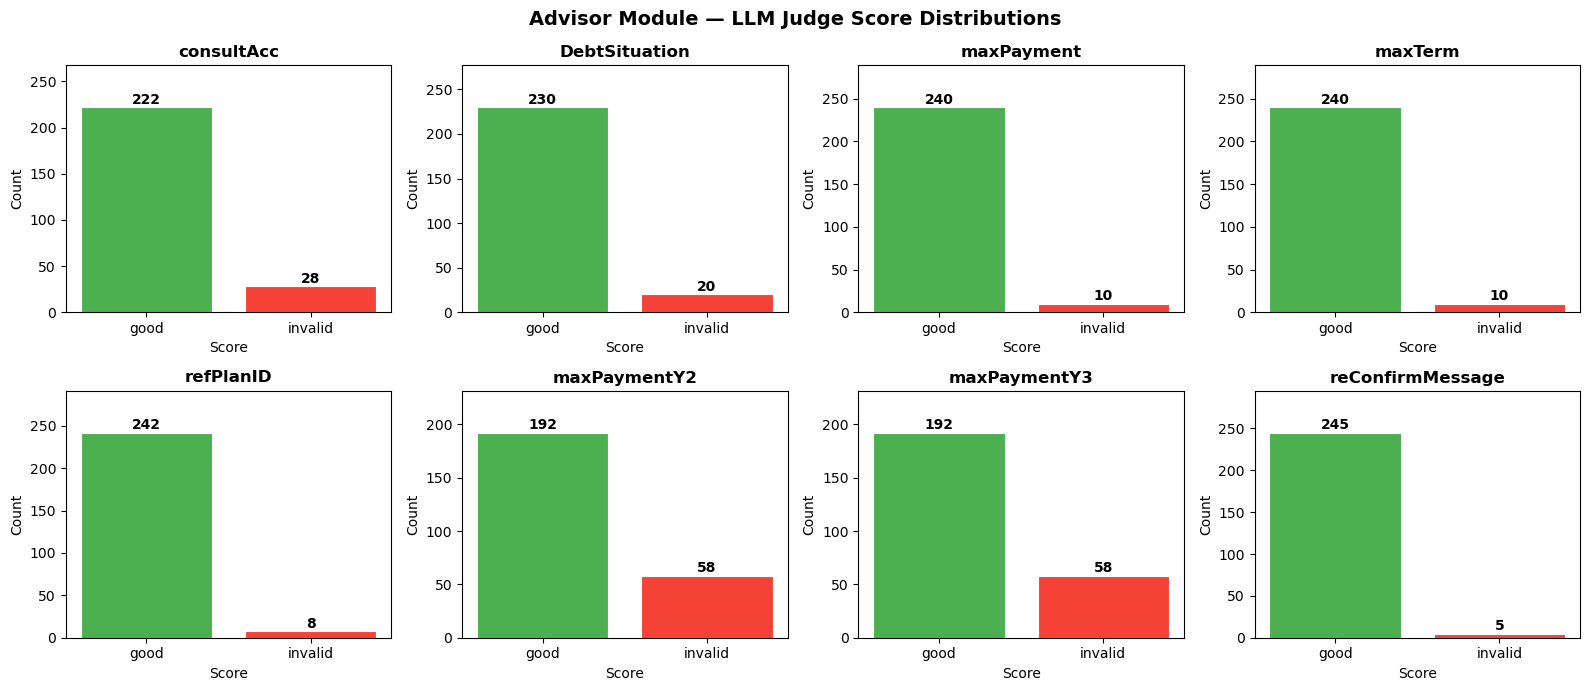

Chart saved → advisor_score_distribution.png


In [9]:
n_fields = len(SCORE_FIELDS)
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()
fig.suptitle("Advisor Module — LLM Judge Score Distributions", fontsize=14, fontweight="bold")

for ax, f in zip(axes, SCORE_FIELDS):
    counts = df_results[f].value_counts().reindex(LABEL_ORDER, fill_value=0)
    colors = [LABEL_COLORS[lbl] for lbl in LABEL_ORDER]
    bars   = ax.bar(LABEL_ORDER, counts.values, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(f, fontweight="bold")
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    for bar, val in zip(bars, counts.values):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                str(val),
                ha="center", va="bottom", fontsize=10, fontweight="bold",
            )
    ax.set_ylim(0, max(counts.values) * 1.2 + 1)

plt.tight_layout()
plt.savefig("advisor_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → advisor_score_distribution.png")

### Score distributions by mode (EXTRACT vs CLARIFY)

In [10]:
mode_groups = sorted(df_results["mode"].unique())
print("=" * 60)
print("SCORE DISTRIBUTIONS — by mode")
print("=" * 60)

for mode in mode_groups:
    sub = df_results[df_results["mode"] == mode]
    print(f"\n  mode: {mode}  (n={len(sub)})")
    for f in SCORE_FIELDS:
        counts = sub[f].value_counts()
        total  = counts.sum()
        print(f"    {f:20s}: ", end="")
        for lbl in LABEL_ORDER:
            n = counts.get(lbl, 0)
            print(f"{lbl}={n} ({n/total:.0%})  ", end="")
        print()

SCORE DISTRIBUTIONS — by mode

  mode: CLARIFY  (n=75)
    consultAcc          : good=69 (92%)  invalid=6 (8%)  
    DebtSituation       : good=71 (95%)  invalid=4 (5%)  
    maxPayment          : good=71 (95%)  invalid=4 (5%)  
    maxTerm             : good=71 (95%)  invalid=4 (5%)  
    refPlanID           : good=71 (95%)  invalid=4 (5%)  
    maxPaymentY2        : good=51 (68%)  invalid=24 (32%)  
    maxPaymentY3        : good=51 (68%)  invalid=24 (32%)  
    reConfirmMessage    : good=70 (93%)  invalid=5 (7%)  

  mode: EXTRACT  (n=175)
    consultAcc          : good=153 (87%)  invalid=22 (13%)  
    DebtSituation       : good=159 (91%)  invalid=16 (9%)  
    maxPayment          : good=169 (97%)  invalid=6 (3%)  
    maxTerm             : good=169 (97%)  invalid=6 (3%)  
    refPlanID           : good=171 (98%)  invalid=4 (2%)  
    maxPaymentY2        : good=141 (81%)  invalid=34 (19%)  
    maxPaymentY3        : good=141 (81%)  invalid=34 (19%)  
    reConfirmMessage    : good=

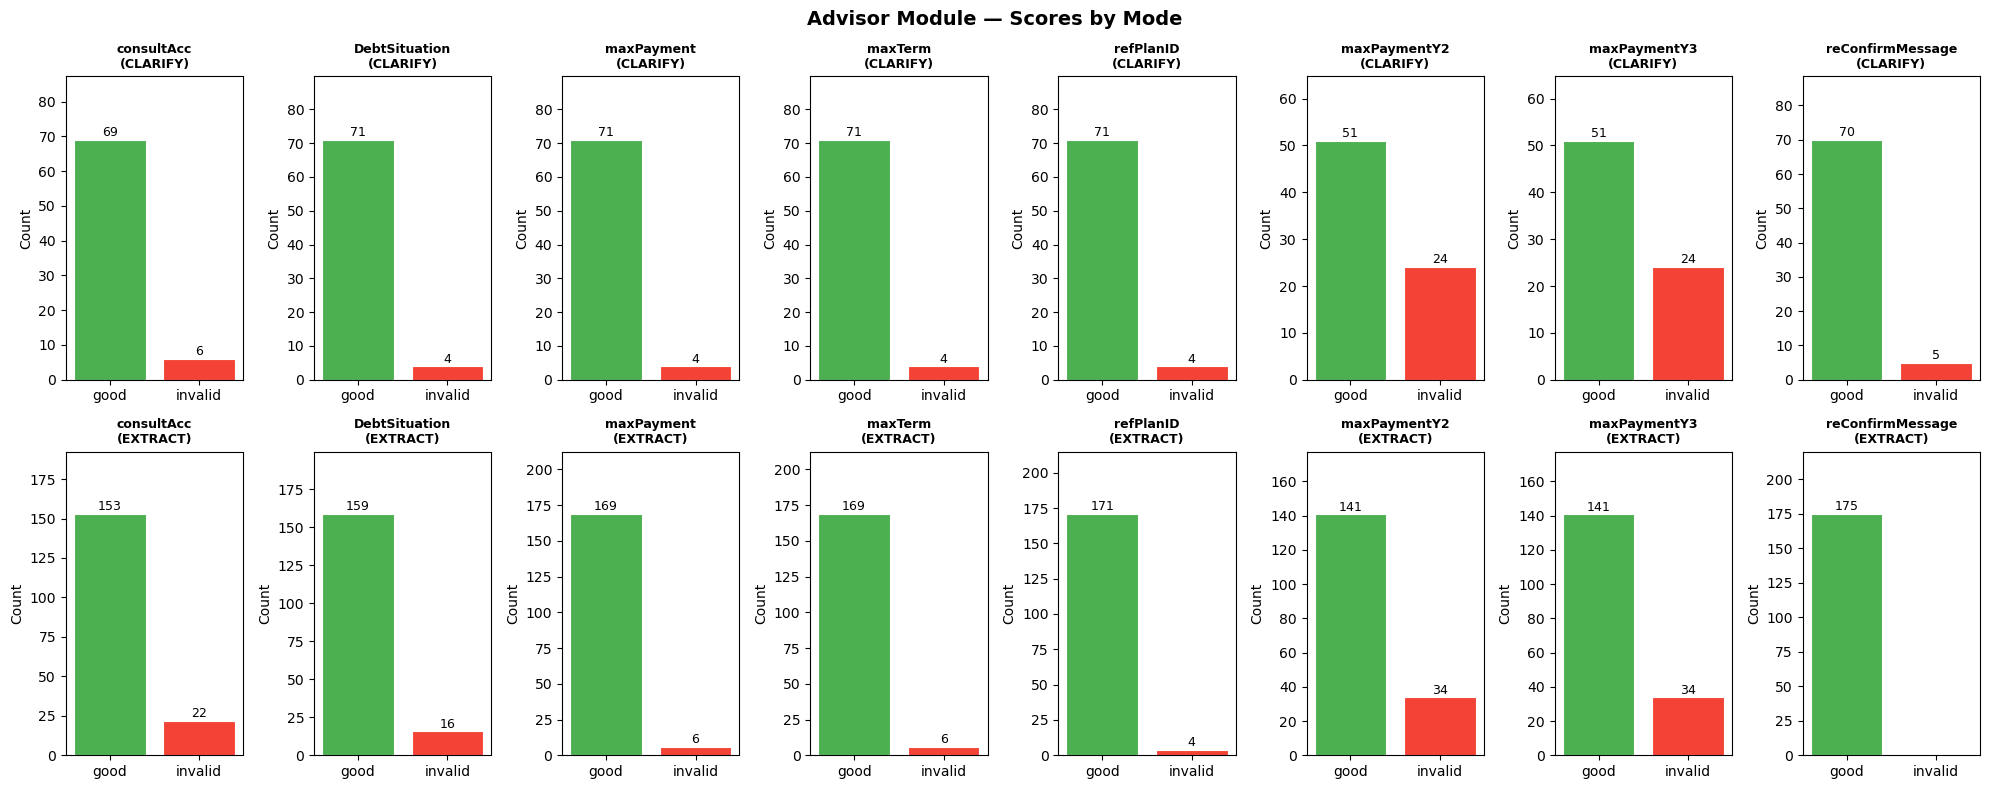

Chart saved → advisor_score_by_mode.png


In [11]:
n_modes = len(mode_groups)
fig, axes = plt.subplots(
    n_modes, len(SCORE_FIELDS),
    figsize=(20, 4 * n_modes),
    sharey=False,
)
if n_modes == 1:
    axes = [axes]

fig.suptitle("Advisor Module — Scores by Mode", fontsize=14, fontweight="bold")

for row_i, mode in enumerate(mode_groups):
    sub = df_results[df_results["mode"] == mode]
    for col_i, f in enumerate(SCORE_FIELDS):
        ax = axes[row_i][col_i]
        counts = sub[f].value_counts().reindex(LABEL_ORDER, fill_value=0)
        colors = [LABEL_COLORS[lbl] for lbl in LABEL_ORDER]
        bars   = ax.bar(LABEL_ORDER, counts.values, color=colors, edgecolor="white", linewidth=0.8)
        ax.set_title(f"{f}\n({mode})", fontsize=9, fontweight="bold")
        ax.set_ylabel("Count")
        for bar, val in zip(bars, counts.values):
            if val > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.2,
                    str(val),
                    ha="center", va="bottom", fontsize=9,
                )
        ax.set_ylim(0, max(counts.values) * 1.25 + 1)

plt.tight_layout()
plt.savefig("advisor_score_by_mode.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → advisor_score_by_mode.png")

### Field accuracy (good rate) per field

FIELD ACCURACY (good rate)
  consultAcc          : good=88.8%  |  invalid=11.2%
  DebtSituation       : good=92.0%  |  invalid=8.0%
  maxPayment          : good=96.0%  |  invalid=4.0%
  maxTerm             : good=96.0%  |  invalid=4.0%
  refPlanID           : good=96.8%  |  invalid=3.2%
  maxPaymentY2        : good=76.8%  |  invalid=23.2%
  maxPaymentY3        : good=76.8%  |  invalid=23.2%
  reConfirmMessage    : good=98.0%  |  invalid=2.0%


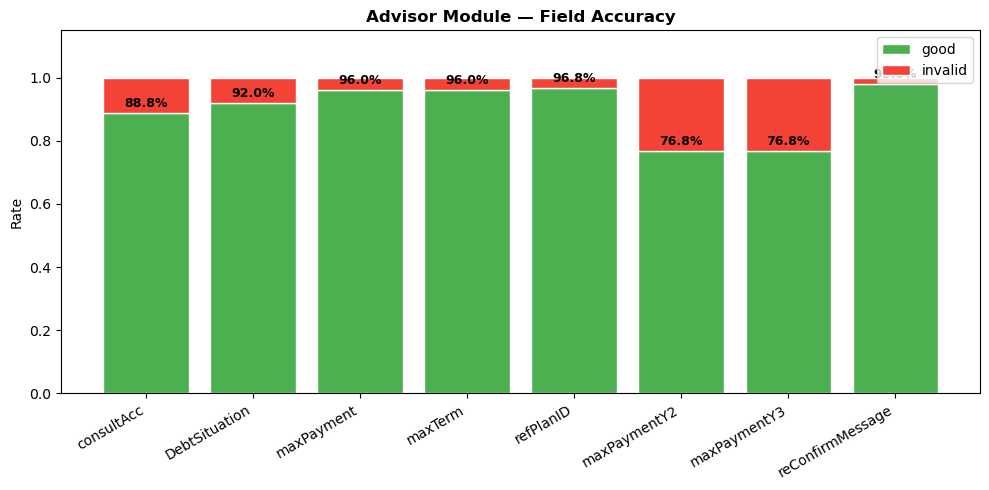

Chart saved → advisor_field_accuracy.png


,field,total,good,invalid,good_rate,invalid_rate
0,consultAcc,250,222,28,88.8%,11.2%
1,DebtSituation,250,230,20,92.0%,8.0%
2,maxPayment,250,240,10,96.0%,4.0%
3,maxTerm,250,240,10,96.0%,4.0%
4,refPlanID,250,242,8,96.8%,3.2%
5,maxPaymentY2,250,192,58,76.8%,23.2%
6,maxPaymentY3,250,192,58,76.8%,23.2%
7,reConfirmMessage,250,245,5,98.0%,2.0%


In [12]:
print("=" * 60)
print("FIELD ACCURACY (good rate)")
print("=" * 60)

acc_rows = []
for f in SCORE_FIELDS:
    total   = df_results[f].notna().sum()
    n_good  = (df_results[f] == "good").sum()
    n_inv   = (df_results[f] == "invalid").sum()
    good_r  = n_good / total if total else 0
    inv_r   = n_inv  / total if total else 0
    print(f"  {f:20s}: good={good_r:.1%}  |  invalid={inv_r:.1%}")
    acc_rows.append({
        "field":       f,
        "total":       total,
        "good":        n_good,
        "invalid":     n_inv,
        "good_rate":   f"{good_r:.1%}",
        "invalid_rate": f"{inv_r:.1%}",
    })

df_acc = pd.DataFrame(acc_rows)

# Bar chart of good rates
fig, ax = plt.subplots(figsize=(10, 5))
good_rates = [df_results[f].eq("good").sum() / df_results[f].notna().sum() for f in SCORE_FIELDS]
inv_rates  = [df_results[f].eq("invalid").sum() / df_results[f].notna().sum() for f in SCORE_FIELDS]
x = range(len(SCORE_FIELDS))
bars_good = ax.bar(x, good_rates, color="#4caf50", label="good", edgecolor="white")
bars_inv  = ax.bar(x, inv_rates,  bottom=good_rates, color="#f44336", label="invalid", edgecolor="white")
ax.set_xticks(list(x))
ax.set_xticklabels(SCORE_FIELDS, rotation=30, ha="right")
ax.set_ylabel("Rate")
ax.set_ylim(0, 1.15)
ax.set_title("Advisor Module — Field Accuracy", fontweight="bold")
ax.legend(loc="upper right")
for bar, rate in zip(bars_good, good_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 0.01,
        f"{rate:.1%}",
        ha="center", va="bottom", fontsize=9, fontweight="bold",
    )
plt.tight_layout()
plt.savefig("advisor_field_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → advisor_field_accuracy.png")
df_acc

### Cases flagged `invalid` on any field

In [13]:
invalid_mask = (df_results[SCORE_FIELDS] == "invalid").any(axis=1)
df_invalid   = df_results[invalid_mask][["mode", "testId", "userMessage"] + SCORE_FIELDS].reset_index(drop=True)

print(f"Cases with at least one 'invalid' score: {len(df_invalid)} / {len(df_results)}")
if len(df_invalid):
    print("\nBreakdown by mode:")
    print(df_invalid["mode"].value_counts().to_string())
    display(df_invalid)

Cases with at least one 'invalid' score: 88 / 250

Breakdown by mode:
mode
EXTRACT    59
CLARIFY    29


,mode,testId,userMessage,consultAcc,DebtSituation,maxPayment,maxTerm,refPlanID,maxPaymentY2,maxPaymentY3,reConfirmMessage
0,EXTRACT,TC-0004,ยอดหนี้รวมสูงกว่ากำลังจ่าย อยากปรับโครงสร้างให...,invalid,good,good,good,good,good,good,good
1,EXTRACT,TC-0020,เดือนนี้มีค่าใช้จ่ายก้อนใหญ่ชั่วคราว แต่รายได้...,invalid,good,good,good,good,good,good,good
2,EXTRACT,TC-0025,เดือนนี้มีค่าใช้จ่ายก้อนใหญ่ชั่วคราว แต่รายได้...,invalid,good,good,good,good,good,good,good
3,EXTRACT,TC-0030,เดือนนี้มีค่าใช้จ่ายก้อนใหญ่ชั่วคราว แต่รายได้...,invalid,good,good,good,good,good,good,good
4,EXTRACT,TC-0036,รายได้ครอบครัวลดลงถาวร ไม่มีรายได้เสริมมาช่วยแ...,invalid,invalid,good,good,good,good,good,good
...,...,...,...,...,...,...,...,...,...,...,...
83,CLARIFY,TC-0233,แผนที่ 2ปีที่ 2 ผ่อนสูงไปค่ะ,good,good,good,good,good,invalid,invalid,good
84,CLARIFY,TC-0236,แผนนี้ดอกเบี้ยรวมสูงไป ปรับให้ดอกถูกลงได้ไหม,good,good,good,good,good,invalid,invalid,good
85,CLARIFY,TC-0241,แผนที่ให้มามียอดปิดสูงเกินไป มีทางปรับไหม,good,good,good,good,good,invalid,invalid,good
86,CLARIFY,TC-0245,แผนที่ 2ผ่อนนานไป อยากปิดเร็วกว่านี้,invalid,invalid,invalid,invalid,invalid,good,good,invalid


### Cases with all fields `good`

In [14]:
all_good_mask = (df_results[SCORE_FIELDS] == "good").all(axis=1)
df_all_good   = df_results[all_good_mask][["mode", "testId"] + SCORE_FIELDS].reset_index(drop=True)

print(f"Cases with all fields 'good': {len(df_all_good)} / {len(df_results)}  ({len(df_all_good)/len(df_results):.1%})")
if len(df_all_good):
    display(df_all_good)

Cases with all fields 'good': 162 / 250  (64.8%)


,mode,testId,consultAcc,DebtSituation,maxPayment,maxTerm,refPlanID,maxPaymentY2,maxPaymentY3,reConfirmMessage
0,EXTRACT,TC-0001,good,good,good,good,good,good,good,good
1,EXTRACT,TC-0002,good,good,good,good,good,good,good,good
2,EXTRACT,TC-0003,good,good,good,good,good,good,good,good
3,EXTRACT,TC-0005,good,good,good,good,good,good,good,good
4,EXTRACT,TC-0006,good,good,good,good,good,good,good,good
...,...,...,...,...,...,...,...,...,...,...
157,CLARIFY,TC-0244,good,good,good,good,good,good,good,good
158,CLARIFY,TC-0246,good,good,good,good,good,good,good,good
159,CLARIFY,TC-0247,good,good,good,good,good,good,good,good
160,CLARIFY,TC-0249,good,good,good,good,good,good,good,good


### Mismatch inspection — per field

For each score field, display every row where the judge returned `"invalid"`.  
Columns shown: `testId`, `mode`, `userMessage`, the expected value (where available), the extracted result, and the judge score for that field.
This makes it easy to spot patterns in what the model is getting wrong.


In [15]:
# ── Mismatch inspection helpers ──────────────────────────────────────────────

# Map each score field to the column(s) that give expected / extracted context
FIELD_CONTEXT = {
    "consultAcc":       {"expected": "expected_consultAcc",       "result": "result_consultAcc"},
    "DebtSituation":    {"expected": "expected_DebtSituation",    "result": "result_DebtSituation"},
    "maxPayment":       {"expected": "expected_maxPayment",       "result": "result_maxPayment"},
    "maxTerm":          {"expected": "expected_maxTerm",          "result": "result_maxTerm"},
    "refPlanID":        {"expected": "expected_refPlanID",        "result": "result_refPlanID"},
    "maxPaymentY2":     {"expected": "expected_maxPaymentY2",     "result": "result_maxPaymentY2"},
    "maxPaymentY3":     {"expected": "expected_maxPaymentY3",     "result": "result_maxPaymentY3"},
    "reConfirmMessage": {"expected": "expected_reConfirmMessage", "result": "result_reConfirmMessage"},
}

BASE_COLS = ["testId", "mode", "userMessage"]


def show_mismatches(field: str) -> None:
    """Print and display the mismatch rows for a single score field."""
    ctx     = FIELD_CONTEXT[field]
    mask    = df_results[field] == "invalid"
    n_total = len(df_results)
    n_inv   = mask.sum()

    print(f"{'─' * 60}")
    print(f"  Field : {field}")
    print(f"  Invalid : {n_inv} / {n_total}  ({n_inv / n_total:.1%})")

    if n_inv == 0:
        print("  ✓ No mismatches — all rows scored 'good'.")
        return

    # Build display columns — include expected / result only if they exist
    disp_cols = BASE_COLS[:] + [f"input_{field}"]
    for role in ("expected", "result"):
        col = ctx[role]
        if col in df_results.columns:
            disp_cols.append(col)
    df_mis = (
        df_results.loc[mask, disp_cols]
        .reset_index(drop=True)
    )

    print(f"  Breakdown by mode:")
    print(df_mis["mode"].value_counts().to_string())
    print()
    display(df_mis)


# ── Run for every score field ─────────────────────────────────────────────────
for _field in SCORE_FIELDS:
    show_mismatches(_field)


────────────────────────────────────────────────────────────
  Field : consultAcc
  Invalid : 28 / 250  (11.2%)
  Breakdown by mode:
mode
EXTRACT    22
CLARIFY     6



,testId,mode,userMessage,input_consultAcc,result_consultAcc
0,TC-0004,EXTRACT,ยอดหนี้รวมสูงกว่ากำลังจ่าย อยากปรับโครงสร้างให...,NaN,"xxxxxx500028,xxxxxx500029,xxxxxx500030"
1,TC-0020,EXTRACT,เดือนนี้มีค่าใช้จ่ายก้อนใหญ่ชั่วคราว แต่รายได้...,NaN,"xxxxxx500140,xxxxxx500141,xxxxxx500142"
2,TC-0025,EXTRACT,เดือนนี้มีค่าใช้จ่ายก้อนใหญ่ชั่วคราว แต่รายได้...,NaN,"xxxxxx500175,xxxxxx500176,xxxxxx500177"
3,TC-0030,EXTRACT,เดือนนี้มีค่าใช้จ่ายก้อนใหญ่ชั่วคราว แต่รายได้...,NaN,"xxxxxx500210,xxxxxx500211,xxxxxx500212"
4,TC-0036,EXTRACT,รายได้ครอบครัวลดลงถาวร ไม่มีรายได้เสริมมาช่วยแ...,NaN,"xxxxxx500252,xxxxxx500253,xxxxxx500254"
5,TC-0041,EXTRACT,รายได้ครอบครัวลดลงถาวร ไม่มีรายได้เสริมมาช่วยแ...,NaN,"xxxxxx500287,xxxxxx500288,xxxxxx500289"
6,TC-0046,EXTRACT,รายได้ครอบครัวลดลงถาวร ไม่มีรายได้เสริมมาช่วยแ...,NaN,"xxxxxx500322,xxxxxx500323,xxxxxx500324"
7,TC-0052,EXTRACT,เพิ่งเกษียณ รายได้เหลือจากเงินบำนาญเท่านั้น จ่...,NaN,"xxxxxx500364,xxxxxx500365,xxxxxx500366"
8,TC-0057,EXTRACT,เพิ่งเกษียณ รายได้เหลือจากเงินบำนาญเท่านั้น จ่...,NaN,"xxxxxx500399,xxxxxx500400,xxxxxx500401"
9,TC-0062,EXTRACT,เพิ่งเกษียณ รายได้เหลือจากเงินบำนาญเท่านั้น จ่...,NaN,"xxxxxx500434,xxxxxx500435,xxxxxx500436"


────────────────────────────────────────────────────────────
  Field : DebtSituation
  Invalid : 20 / 250  (8.0%)
  Breakdown by mode:
mode
EXTRACT    16
CLARIFY     4



,testId,mode,userMessage,input_DebtSituation,result_DebtSituation
0,TC-0036,EXTRACT,รายได้ครอบครัวลดลงถาวร ไม่มีรายได้เสริมมาช่วยแ...,NaN,PermanentAffordability
1,TC-0040,EXTRACT,รายรับประจำลดลงแบบต่อเนื่อง จึงต้องการแผนที่จ่...,NaN,PermanentAffordability
2,TC-0045,EXTRACT,รายรับประจำลดลงแบบต่อเนื่อง จึงต้องการแผนที่จ่...,NaN,PermanentAffordability
3,TC-0047,EXTRACT,เงินเดือนลดลงระยะยาว ต้องปรับค่างวดให้ต่ำกว่าข...,NaN,PermanentAffordability
4,TC-0064,EXTRACT,ตอนนี้ตกงาน จ่ายเท่าเดิมไม่ไหวแล้ว ขอปรับทุกบั...,NaN,NaN
5,TC-0099,EXTRACT,รายรับประจำลดลงแบบต่อเนื่อง จึงต้องการแผนที่จ่...,DebtBurden,PermanentAffordability
6,TC-0101,EXTRACT,เงินเดือนลดลงระยะยาว ต้องปรับค่างวดให้ต่ำกว่าข...,DebtBurden,PermanentAffordability
7,TC-0102,EXTRACT,รายได้ถูกปรับลดถาวรแล้ว ไม่น่าจะกลับไปจ่ายเท่า...,DebtBurden,PermanentAffordability
8,TC-0103,EXTRACT,บริษัทลดชั่วโมงทำงานระยะยาว ทำให้กำลังผ่อนลดลง...,DebtBurden,PermanentAffordability
9,TC-0104,EXTRACT,รายรับประจำลดลงแบบต่อเนื่อง จึงต้องการแผนที่จ่...,DebtBurden,PermanentAffordability


────────────────────────────────────────────────────────────
  Field : maxPayment
  Invalid : 10 / 250  (4.0%)
  Breakdown by mode:
mode
EXTRACT    6
CLARIFY    4



...

,testId,mode,userMessage,input_maxPaymentY2,result_maxPaymentY2
0,TC-0081,EXTRACT,ค่าใช้จ่ายประจำสูงจนเงินเดือนเหลือไม่พอผ่อนเต็...,NaN,0.0
1,TC-0085,EXTRACT,ตอนนี้หนี้หลายทางเกินรายรับ อยากลดค่างวดลงให้พ...,NaN,0.0
2,TC-0086,EXTRACT,ค่าใช้จ่ายประจำสูงจนเงินเดือนเหลือไม่พอผ่อนเต็...,NaN,0.0
3,TC-0087,EXTRACT,ยอดหนี้รวมสูงกว่ากำลังจ่าย อยากปรับโครงสร้างให...,NaN,0.0
4,TC-0090,EXTRACT,ลูกค้าของผมจ่ายเงินล่าช้า เลยขาดสภาพคล่องแค่ระ...,NaN,0.0
5,TC-0093,EXTRACT,เดือนนี้เงินเดือนออกช้า แต่คาดว่าจะกลับมาปกติเ...,NaN,0.0
6,TC-0094,EXTRACT,ช่วงนี้เงินสดสะดุดชั่วคราวเพราะรอค่าคอมมิชชั่น...,NaN,0.0
7,TC-0096,EXTRACT,เดือนนี้มีค่าใช้จ่ายก้อนใหญ่ชั่วคราว แต่รายได้...,NaN,0.0
8,TC-0097,EXTRACT,ตอนนี้หมุนเงินไม่ทันชั่วคราว รอโอนเงินจากงานพิ...,NaN,0.0
9,TC-0099,EXTRACT,รายรับประจำลดลงแบบต่อเนื่อง จึงต้องการแผนที่จ่...,NaN,0.0


────────────────────────────────────────────────────────────
  Field : maxPaymentY3
  Invalid : 58 / 250  (23.2%)
  Breakdown by mode:
mode
EXTRACT    34
CLARIFY    24



,testId,mode,userMessage,input_maxPaymentY3,result_maxPaymentY3
0,TC-0081,EXTRACT,ค่าใช้จ่ายประจำสูงจนเงินเดือนเหลือไม่พอผ่อนเต็...,NaN,0.0
1,TC-0085,EXTRACT,ตอนนี้หนี้หลายทางเกินรายรับ อยากลดค่างวดลงให้พ...,NaN,0.0
2,TC-0086,EXTRACT,ค่าใช้จ่ายประจำสูงจนเงินเดือนเหลือไม่พอผ่อนเต็...,NaN,0.0
3,TC-0087,EXTRACT,ยอดหนี้รวมสูงกว่ากำลังจ่าย อยากปรับโครงสร้างให...,NaN,0.0
4,TC-0090,EXTRACT,ลูกค้าของผมจ่ายเงินล่าช้า เลยขาดสภาพคล่องแค่ระ...,NaN,0.0
5,TC-0093,EXTRACT,เดือนนี้เงินเดือนออกช้า แต่คาดว่าจะกลับมาปกติเ...,NaN,0.0
6,TC-0094,EXTRACT,ช่วงนี้เงินสดสะดุดชั่วคราวเพราะรอค่าคอมมิชชั่น...,NaN,0.0
7,TC-0096,EXTRACT,เดือนนี้มีค่าใช้จ่ายก้อนใหญ่ชั่วคราว แต่รายได้...,NaN,0.0
8,TC-0097,EXTRACT,ตอนนี้หมุนเงินไม่ทันชั่วคราว รอโอนเงินจากงานพิ...,NaN,0.0
9,TC-0099,EXTRACT,รายรับประจำลดลงแบบต่อเนื่อง จึงต้องการแผนที่จ่...,NaN,0.0


────────────────────────────────────────────────────────────
  Field : reConfirmMessage
  Invalid : 5 / 250  (2.0%)


KeyError: "['input_reConfirmMessage'] not in index"